<a href="https://colab.research.google.com/github/RunPhase/BigData_Visualization/blob/main/%EB%B6%84%ED%8F%AC%EC%9A%94%EC%95%BD%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown

gdown.download('https://bit.ly/3pK7iuu', 'ns_book7.csv', quiet=False)

Downloading...
From: https://bit.ly/3pK7iuu
To: /content/ns_book7.csv
100%|██████████| 53.8M/53.8M [00:00<00:00, 94.0MB/s]


'ns_book7.csv'

In [ ]:
import pandas as pd

ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


데이터를 한눈에 파악하려면 그래프가 가장 좋은 방법입니다.

- 산점도(scatter plot)
- 히스토그램(histogram)
- 상자수염그림(box-and-whisker plot)

## 산점도 그리기

**데이터를 화면에 뿌리듯 그리는 그래프입니다.**

- 두 변수(variable)혹은 두 가지 특성(feature)값을 직교 좌표계에 점으로 나타내는 그래프

- 맷플롯립(matplotlib) 패키지 필요

- 파이썬의 다양한 데이터 과학 패키지들도 맷플롯립을 활용할 정도로 널리 사용하므로 구글 코랩에서도 기본 설치되어 있습니다.

### scatter()함수
함수 첫 번째 매개변수에 4개 포인트의 x축 좌표를 전달하고 두번째 매개변수에 y축 좌표를 전달합니다.

다음처럼 scatter()함수를 호출한 다음에는 show()함수를 호출하여 그래프를 출력합니다.

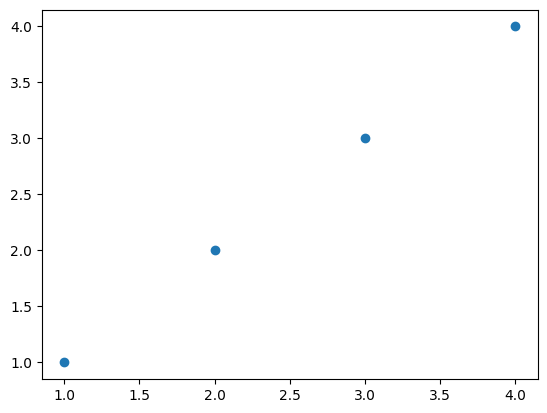

In [ ]:
import matplotlib.pyplot as plt

plt.scatter([1,2,3,4], [1,2,3,4])
plt.show()

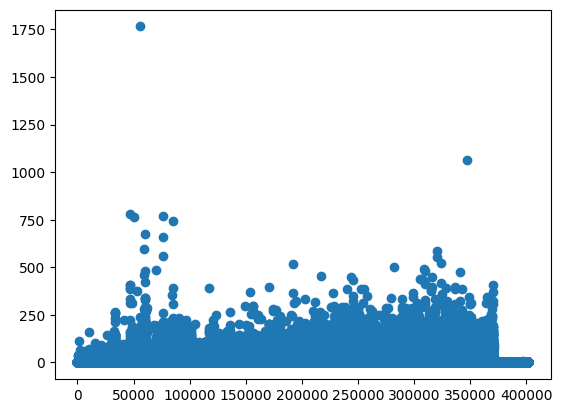

In [ ]:
plt.scatter(ns_book7['번호'], ns_book7['대출건수'])
plt.show()

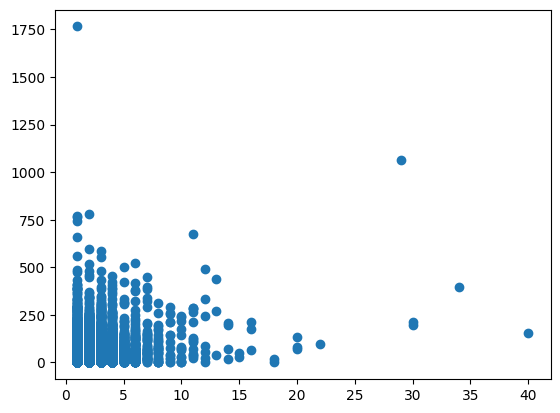

In [ ]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'])
plt.show()

## 투명도 조절하기

맷플롯립은 alpha매개변수에 0~1사이의 값으로 투명도를 지정할 수 있습니다.

투명도를 주더라도 데이터가 많이 중첩된 부분은 짙게 나타납니다.

매개변수를 0.1로 지정하여 다시 그려보기.

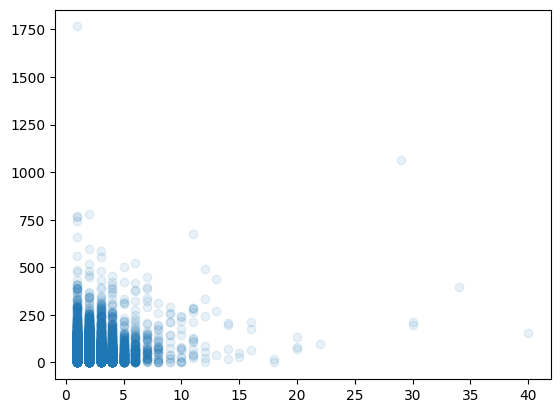

In [ ]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

예상대로 왼쪽 모서리 아래 근처에 중첩된 데이터포인트가 많습니다. 투명도를 더 낮추더라도 왼쪽 모서리 아래 근처는 여전히 짙게 나타나는데, 이는 대부분의 도서권수가 적다는 것을 의미합니다.

예전 describe()메서드로 기술통계를 확인했을 때 도서권수의 백분위90%에 위치한 값은 2였습니다.

대부분의 도서권수가 2보다 작다는 것을 알 수 있습니다.

도서권수가 대부분 작은 값이기 때문에 도서권수와 대출건수 사이의 관계를 파악하기 어렵습니다.

양의 상관관계 - 도서권수가 많으면 대출건수도 많다

음의 상관관계 - 도서권수가 적을수록 대출건수가 많다

'도서권수'열 대신에 '대출건수'열을 '도서권수'열로 나눈 값 사용

도서권수당 대출건수를 x축에 두고 대출건수를 y축에 놓습니다.

대출건수가 높다면 도서권수 당 대출건수도 높을 것입니다.

'대출건수'열을 '도서권수'열로 나눈 값을 average_borrows변수에 저장하고, 이 변수와 '대출건수'열을 차례대로 scatter()함수에 전달합니다.

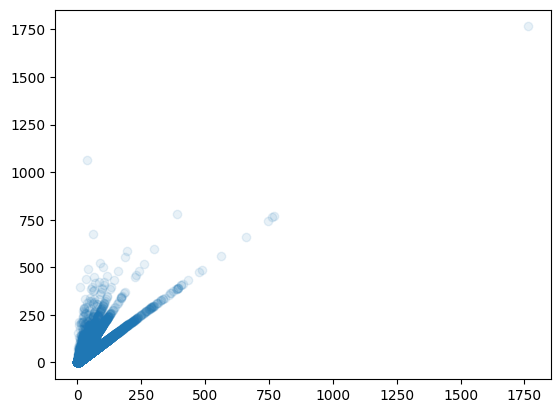

In [ ]:
average_borrows = ns_book7['대출건수']/ns_book7['도서권수']
plt.scatter(average_borrows, ns_book7['대출건수'], alpha=0.1)
plt.show()

출력된 그래프를 보면 x축(도서권수 당 대출건수)이 증가함에 따라 y축(대출건수)이 증가하는 것을 뚜렷하게 볼 수 있습니다.

두 특성사이에는 '양의 상관관계'가 있다고 말할 수 있습니다.

## 히스토그램 그리기

: 수치형 특성의 값을 일정한 구간(bin)으로 나누어 구간 안에 포함된 데이터 개수를 막대 그래프로 표현

도수(frequency) - 구간 안에 속한 데이터 개수

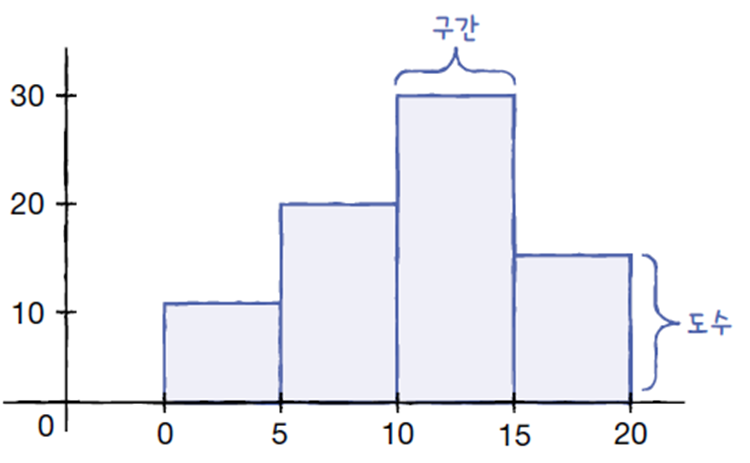

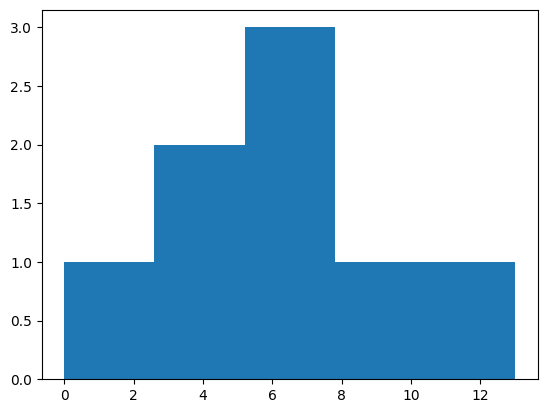

In [ ]:
plt.hist([0,3,5,6,7,7,9,13], bins=5)
plt.show()

###histogram_bin_edges()함수
구간의 경곗값을 출력

In [ ]:
import numpy as np

np.histogram_bin_edges([0,3,5,6,7,7,9,13], bins=5)

array([ 0. ,  2.6,  5.2,  7.8, 10.4, 13. ])

random()함수 표준정규분포를 따르는 랜덤한 실수를 생성할 수 있습니다.

이 함수에 샘플 개수를 전달하여 난수(random number)를 생성해 보겠습니다.

In [ ]:
# 랜덤한 실수를 1,000개 생성
np.random.seed(42)
random_samples = np.random.randn(1000)

seed()함수를 사용하면 유사난수를 생성할 수 있습니다. 즉 가짜 난수입니다.

In [ ]:
print(np.mean(random_samples), np.std(random_samples))

0.01933205582232549 0.9787262077473543


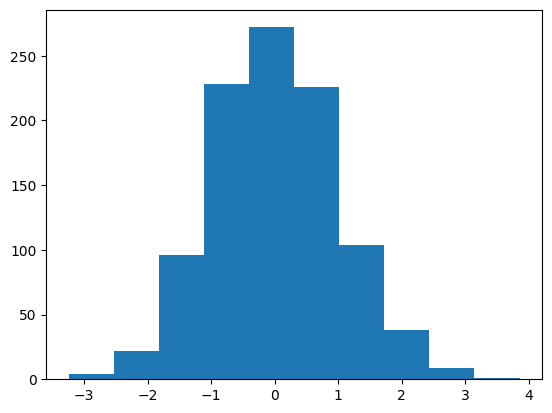

In [ ]:
plt.hist(random_samples)
plt.show()

남산도서관 대출 데이터에서 수치 데이터의 분포를 확인하기 위해 히스토그램

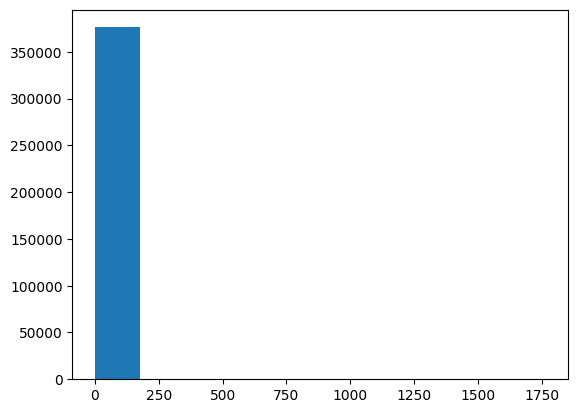

In [ ]:
plt.hist(ns_book7['대출건수'])
plt.show()

## 구간조정하기

### 로그스케일(log scale)

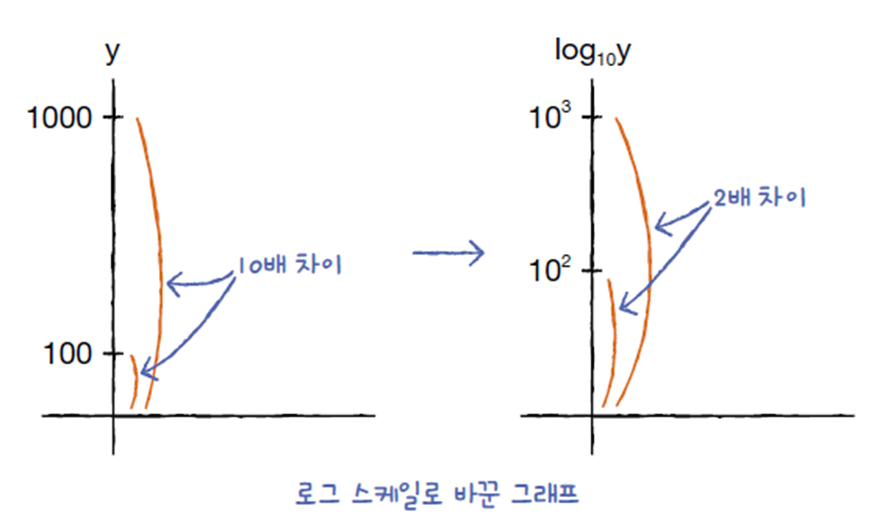

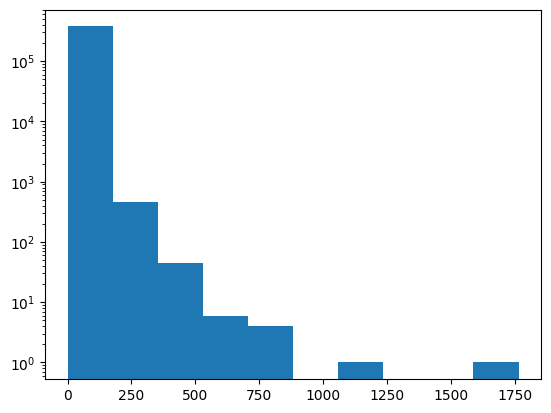

In [ ]:
plt.hist(ns_book7['대출건수'])
plt.yscale('log')
plt.show()

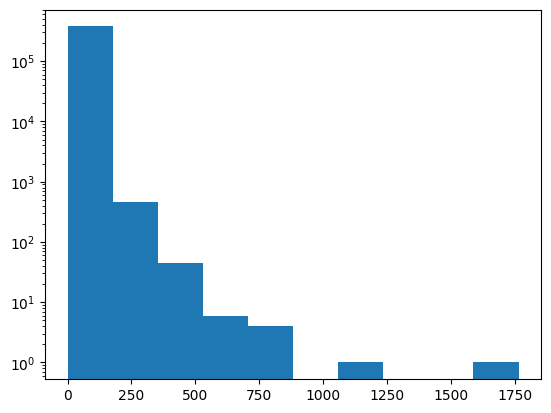

In [ ]:
plt.hist(ns_book7['대출건수'], log=True)
plt.show()

맷플롯립은 기본적으로 밑이 10인 로그 함수를 사용합니다.

### bins매개변수
x축의 구간을 세세하게 나누어 보기


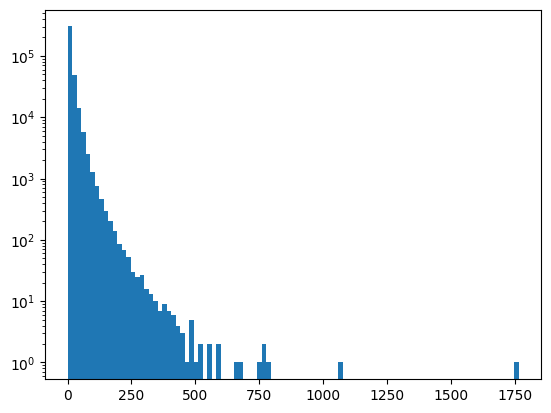

In [ ]:
plt.hist(ns_book7['대출건수'], bins=100)
plt.yscale('log')
plt.show()

대출건수가0이 가장 많고 대출건수가 증가함에 따라 도수가 줄어듭니다.

이런 그래프는 정규분포와는 거리가 멀다.

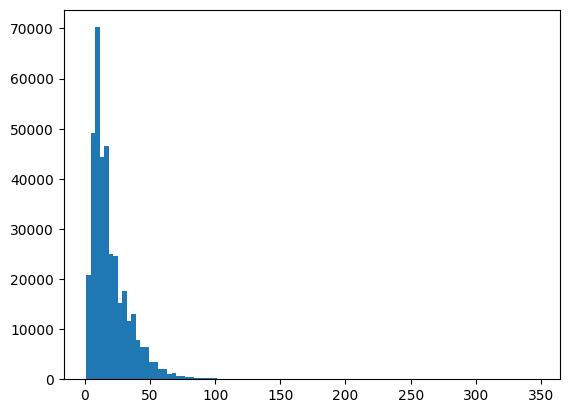

In [ ]:
# 도서명의 길이 히스토그램
# apply()메서드를 사용하여 파이썬의 len()함수를 적용하면
#title_len변수는 각 도서명의 길이가 저장된 판다스 시리즈 객체가 됩니다.
title_len = ns_book7['도서명'].apply(len)
plt.hist(title_len, bins=100)
plt.show()

앞에서 y축에 로그스케일을 적용했던 것처럼 x축에도 로그스케일을 적용할 수 있습니다.

이렇게 하면 x축을 따라 작은 값과 큰 값의 차이가 줄어들 것입니다.

y축에 로그스케일을 적용하는 ysclae()함수와 비슷하게 xscale()함수를 사용하면 됩니다.